<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Lesson_6_ml_basic_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 6 ML Basic Assignment

## House Price Prediction Using California Housing Data

This notebook loads a California Housing style dataset, performs EDA, trains a regression model, evaluates it, and makes a new prediction.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
# Data Collection and Loading
# In this environment, a public California Housing-style CSV is used and transformed
# to match the sklearn California Housing feature names.

raw = pd.read_csv("housing.csv")

df = pd.DataFrame({
    'MedInc': raw['median_income'],
    'HouseAge': raw['housing_median_age'],
    'AveRooms': raw['total_rooms'] / raw['households'],
    'AveBedrms': raw['total_bedrooms'] / raw['households'],
    'Population': raw['population'],
    'AveOccup': raw['population'] / raw['households'],
    'Latitude': raw['latitude'],
    'Longitude': raw['longitude'],
    'MedHouseVal': raw['median_house_value'] / 100000.0
})

# Handle missing values in AveBedrms
df['AveBedrms'] = df['AveBedrms'].fillna(df['AveBedrms'].median())

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
# Quick Check of Data
print("First five rows:")
print(df.head())

print("\nLast five rows:")
print(df.tail())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

First five rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Last five rows:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18

### Notes
- All features in this dataset are numerical and continuous.
- There are no categorical columns in the processed dataset.
- `MedHouseVal` is the continuous target variable used for regression.

In [14]:
# Check for missing values
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


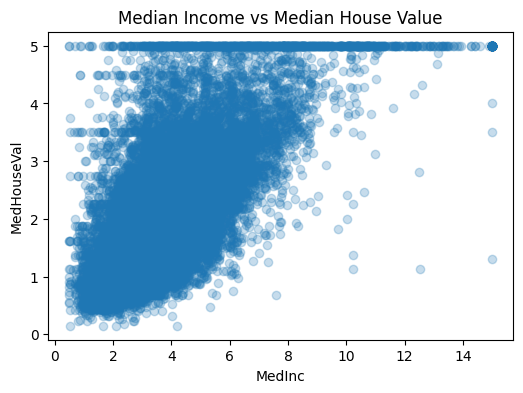

In [15]:
# Visualize MedInc vs target
plt.figure(figsize=(6,4))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.25)
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.title('Median Income vs Median House Value')
plt.show()

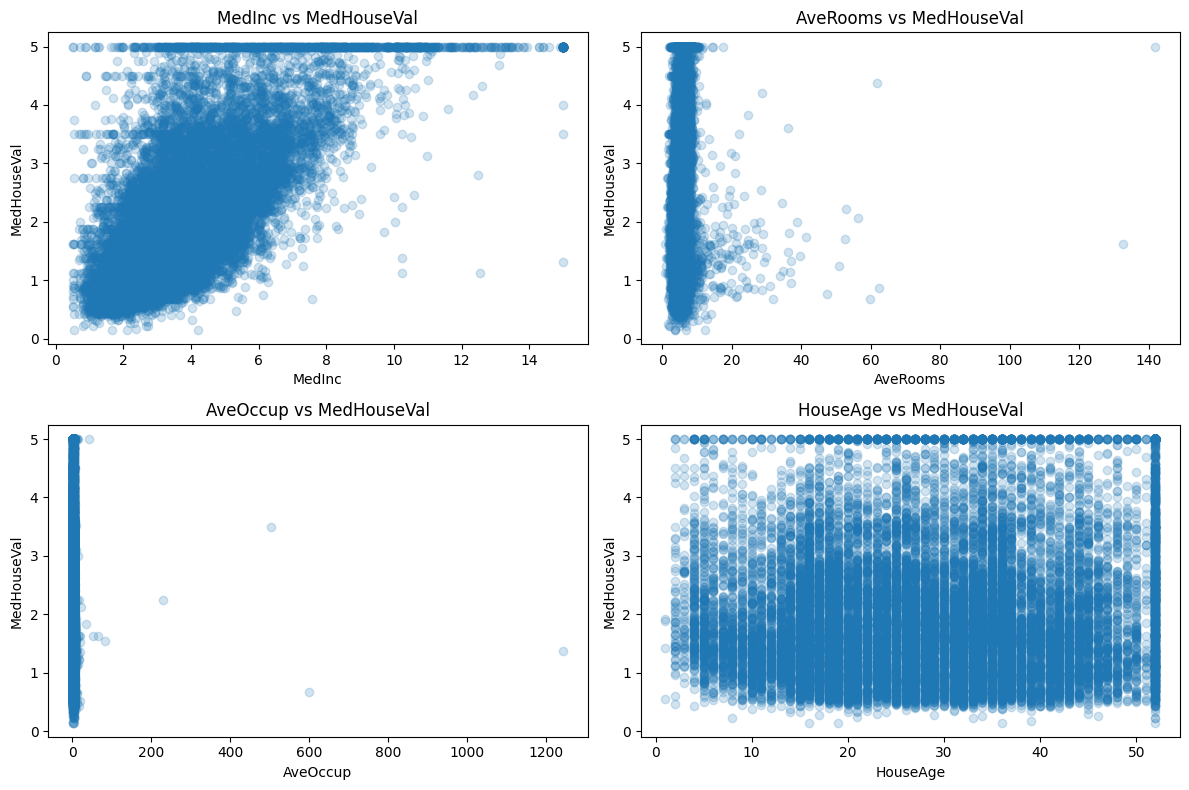

In [16]:
# Function to automate scatter plots for all features vs MedHouseVal
def scatter_plots_vs_target(data, features, target='MedHouseVal'):
    n = len(features)
    rows = int(np.ceil(n / 2))
    plt.figure(figsize=(12, 4 * rows))
    for i, feature in enumerate(features, 1):
        plt.subplot(rows, 2, i)
        plt.scatter(data[feature], data[target], alpha=0.20)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f'{feature} vs {target}')
    plt.tight_layout()
    plt.show()

features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
scatter_plots_vs_target(df, features)

In [17]:
# Split the dataset
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (16512, 8) (16512,)
Testing set shape: (4128, 8) (4128,)


In [18]:
# Train regression model
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=np.abs, ascending=False)

print(coefficients)

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
7   Longitude    -0.433708
6    Latitude    -0.419792
2    AveRooms    -0.123323
1    HouseAge     0.009724
5    AveOccup    -0.003526
4  Population    -0.000002


In [19]:
# Model Evaluation
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")

RMSE: 0.7455
R-squared: 0.5759


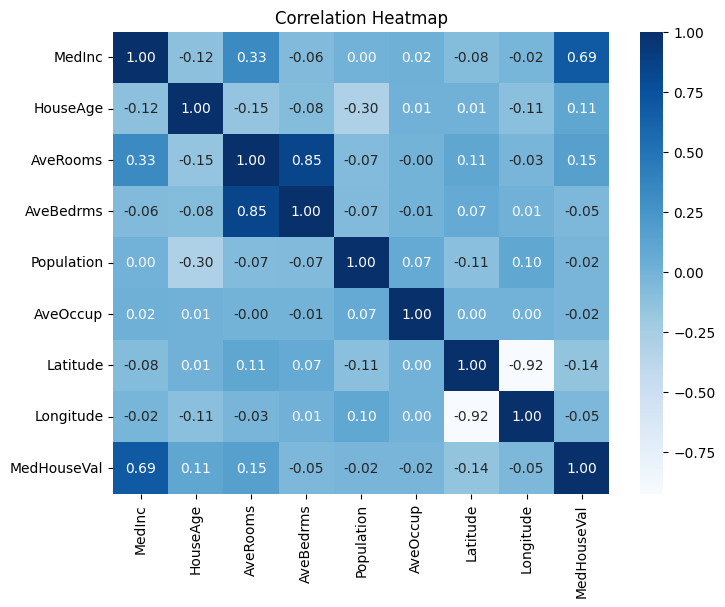

In [20]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

### EDA Insights
- `MedInc` has the strongest positive relationship with house value.
- Location features (`Latitude`, `Longitude`) also have strong influence, showing the geographic nature of housing prices.
- The linear regression model provides a reasonable baseline but leaves room for improvement with more advanced models.

In [21]:
# Predict Median House Value from new feature inputs
new_data = pd.DataFrame([{
    'MedInc': 3,
    'HouseAge': 30,
    'AveRooms': 6,
    'AveBedrms': 1,
    'Population': 1500,
    'AveOccup': 3,
    'Latitude': 34,
    'Longitude': -118
}])

predicted_value = model.predict(new_data)[0]
print(f"Predicted Median House Value (in $100,000 units): {predicted_value:.4f}")
print(f"Predicted Median House Value (USD): ${predicted_value * 100000:,.2f}")

Predicted Median House Value (in $100,000 units): 1.5487
Predicted Median House Value (USD): $154,866.33
